# Entrega de Mineria de Datos 1

***Integrantes:***

***Ignacio Rivera***

***Diego Abarza***

# Contexto
En este estudio veremos los patrones de uso de teléfonos inteligentes y su relación con el nivel de adicción. Utiliza un conjunto de datos que incluye variables demográficas como la edad y el género, junto con métricas de uso digital como horas diarias de pantalla, tiempo en redes sociales, tiempo de juego, horas de sueño, notificaciones y aperturas de aplicaciones.

Los objetivos clave del proyecto parecen ser:

***Exploración de Datos***: Entender la distribución de las variables y la presencia de valores nulos, así como las características generales de la población estudiada.

***Preparación de Datos***: Manejar valores faltantes (como la imputación por moda en addiction_level) y transformar variables categóricas a formatos numéricos (One-Hot Encoding y Ordinal Encoding) para su uso en modelos de Machine Learning.

***Análisis Descriptivo y Visualización***: Investigar la prevalencia de la adicción (se encontró un 70.77% de personas adictas en la muestra), la distribución de los niveles de adicción (con un 81.7% en niveles moderados a severos), la relación entre la edad y los niveles de adicción, y las correlaciones entre el tiempo de pantalla y otras variables de comportamiento digital.

En resumen, el proyecto busca identificar patrones y factores clave asociados con la adicción a los teléfonos inteligentes para comprender mejor este fenómeno.

# Fase 1 Importacion de librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from IPython.display import clear_output as co
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv("/content/Smartphone_Usage_And_Addiction.csv")

# Fase 2 Comprender los Datos

In [ ]:
df.shape

(7500, 16)

In [ ]:
df.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,NaN,0


In [ ]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [ ]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 819
Total de valores nulos de addicted_label = 0


In [ ]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


# Realizaremos un mapeo de datos y una Clasificacion de Variables


'**transaction_id**': categorico nominal ya que es un identificador unico qu enoas ayuda a reconocer o identificar.

'**user_id**': Categórico Nominal, al igual que el anterior, funciona como una etiqueta única por usuario.

'**age**': Numérico Discreto. Generalmente se cuenta en años enteros (aunque en salud extrema podría ser continuo, aquí es discreto).

'**gender**': Categórico Nominal. Son Categorías sin un orden en especifico  (Masculino, Femenino, No binario, etc.).

'**daily_screen_time_hours**': Numérico Continuo. Es una medición de tiempo que puede incluir minutos y segundos (ej. 5.5 horas).

'***social_media_hours***': Numérico Continuo, es una medición de tiempo en este caso seria cuantas horas pasa en redes sociales(admite decimales)

'**gaming_hours**': Numérico Continuo, tambien es una medición de tiempo en este caso cuantas horas juega (admite decimales)

'**work_study_hours**': Numérico Continuo, es una medición de tiempo en este caso cuantas horas estudia la persona (admite decimales)

'**sleep_hours**': Numérico Continuo, es una medición de tiempo en este caso seria las horas que una persona puede dormir o duerme (admite decimales)

'**notifications_per_day**': Numérico Discreto, este surge de un conteo de eventos (no puedes recibir 10.5 notificaciones).

'**app_opens_per_day**': Numérico Discreto, conteo de acciones de apertura (números enteros).

'**weekend_screen_time**': Numérico Continuo, es una medición de tiempo total cuanto timepo en pantalla pasa en el fin de semana.

'**stress_level**': Categórico Ordinal, este generalmente se mide en escalas (Bajo, Medio, Alto) que tienen un orden lógico.

'**academic_work_impact**': Categórico Ordinal, este suele ser una escala de impacto o simplemente si estudia de una manera elevada o no, en este caso YES o NO.

'**addiction_level**': Categórico Ordinal, escala de intensidad que sigue una jerarquía de gravedad (Mild,	Moderate, Severe)**

'**addicted_label**': Categórico Nominal	Generalmente es una clasificación binaria (Sí / No).

# Describe
***En general, estas estadísticas nos dan una primera vista de la centralización, dispersión y forma de las distribuciones de cada variable numérica, lo cual es fundamental para entender el comportamiento de los datos antes de realizar análisis más profundos o construir modelos.***

In [ ]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


# Ejemplo
***El rango de edad de los participantes va de 18 a 35 años, con un promedio de aproximadamente 26.57 años. La desviación estándar (5.19) sugiere una dispersión moderada alrededor de la media.***

# Types
***El siguiente codigo lo utilizaremos para mostrar los tipos de datos de cada columna en el DataFrame df. Esto es útil para entender cómo Pandas interpreta los datos en cada columna (por ejemplo, si son números enteros, números decimales, objetos, etc.), lo cual es crucial para operaciones de limpieza y análisis de datos.***

In [ ]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


# Fase 3 Tratamiento de los datos

#Valores nulos
***hay que identificar y contar la cantidad de valores nulos o ausentes en cada columna de este dataframe, al fianl encontramos 819 valores nulos en addiction_level***


# Graficando valores nulos
***El siguiente código primero identifica y calcula el porcentaje de valores nulos en cada columna de nuestro DataFrame. Luego, muestra esta información en una tabla y la visualiza en un gráfico de barras para que puedas ver rápidamente qué columnas tienen datos faltantes y en qué proporción.
Mas que nada lo hacemos para ver de mejor manera
que se puede observar? : se observa que la columna addiction_label tiene 819 valores nulos representados en un 10.92%***

                 Valores faltantes  Porcentaje (%)
addiction_level                819           10.92


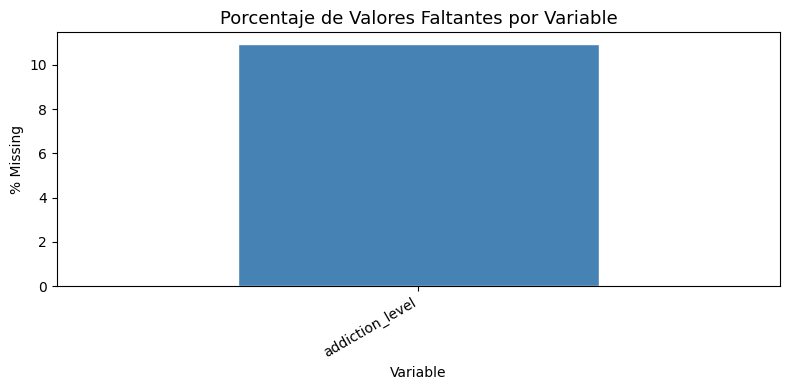

In [ ]:
# Conteo y porcentaje de valores faltantes por columna
missing = pd.DataFrame({
    'Valores faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valores faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(missing)

# Visualización
if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing['Porcentaje (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=13)
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Variable')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# Limpieza de datos nulos
Aca realizamos una limpieza de datos , en donde imputamos los nulos con la MODA

***Para manejar los valores nulos, primero los identificamos y contamos en cada columna, visualizándolos con un gráfico que reveló que la columna addiction_level tenía el 10.92% de sus datos faltantes. Luego, para esta columna categórica ordinal, rellenamos esos 819 valores nulos con la moda (el valor más frecuente) para mantener la integridad de los datos y asegurar la consistencia en el análisis posterior.***

In [ ]:
ctext = ['addiction_level']

for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)

***Como se podra ver aca ya hacemos otra visualizacion de los nulos y podemos ver que ya no hay mas valores faltantes***

In [ ]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 0
Total de valores nulos de addicted_label = 0


# Desarrollo y visualizacion de los datos

***Este código calcula el porcentaje de personas adictas en tu conjunto de datos filtrando los registros donde addicted_label es 1, dividiendo este conteo por el total de registros, y multiplicando por 100 para obtener el porcentaje final, el cual luego se imprime formateado por ejemplo podemos ver que el porcentaje de personas adictas es mayor (70%)***

In [ ]:
porcentaje_adictos = (df[df['addicted_label'] == 1].shape[0] / df.shape[0]) * 100
print(f"El porcentaje de personas adictas es: {porcentaje_adictos:.2f}%")

El porcentaje de personas adictas es: 70.77%


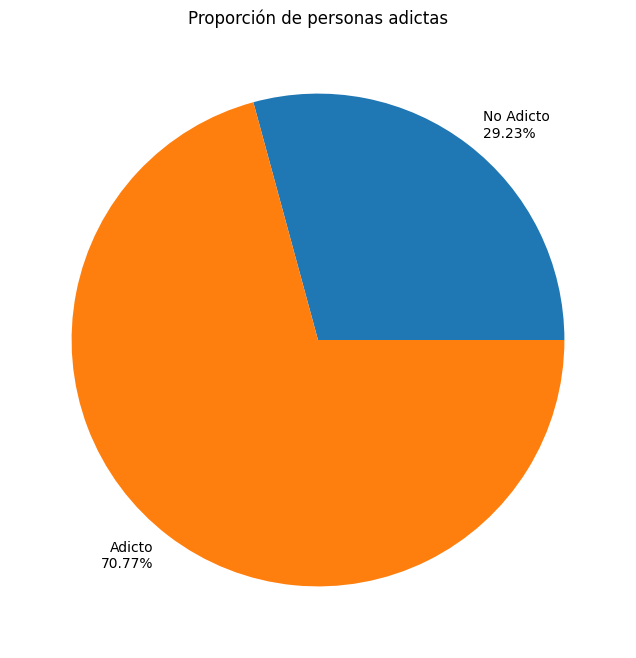

In [ ]:
#conteo de adictos
conteo_adictos = df.groupby('addicted_label').size()

# % no adictos
porc_no_adictos = 100 - porcentaje_adictos

labels = []
labels.append(f'No Adicto\n{porc_no_adictos:.2f}%')
labels.append(f'Adicto\n{porcentaje_adictos:.2f}%')

plt.figure(figsize=(8, 8))
plt.pie(conteo_adictos, labels=labels, autopct='')
plt.title('Proporción de personas adictas')
plt.show()

>Agrupando la totalidad de nuestros datos según la etiqueta principal (addicted_label) para contar cuántas personas caen en la categoría de "Adicto" y cuántas en "No Adicto". Luego, calculamos los porcentajes exactos de cada grupo y los representamos en un gráfico de torta general.

>Para establecer la "línea base" o el panorama general de nuestro problema de estudio. Este gráfico nos revela un hallazgo crítico sobre nuestro dataset: existe un fuerte desbalance. Aproximadamente el 71% de nuestra muestra total clasifica como adicta a las pantallas, frente a solo un 29% que no lo es. Esto nos indica de entrada que, dentro de la población estudiada, el comportamiento adictivo es la norma y no la excepción

In [ ]:
crosstab_result = pd.crosstab(df['addiction_level'], df['addicted_label'])
display(crosstab_result)

addicted_label,0,1
addiction_level,,
Mild,1373,0
Moderate,819,2874
Severe,0,2434


ACA VEMOS LA DISTRIBUCION QUE EXISTEN SEGUN EL NIVEL DE ADICCION EN DONDE VEMOS QUE MILD (LEVE) NO EXISTE NINGUNO Y EN SEVERE TODOS SON CONSIDERADOS ADICTOS

In [ ]:
moderate_df = df[df['addiction_level'] == 'Moderate']
print("Comparación de promedios dentro del nivel 'Moderate' según 'addicted_label':")
display(moderate_df.groupby('addicted_label').mean(numeric_only=True))

Comparación de promedios dentro del nivel 'Moderate' según 'addicted_label':


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,,
0,26.472527,4.522833,2.240696,2.006081,3.259536,6.677582,134.363858,97.107448,6.227790
1,26.433194,8.351427,3.579694,2.033135,3.240438,6.756816,135.382394,97.955811,10.090647


ACA SE PUEDE VER LAS DIFERENCIAS QUE EXISTEN EN LA CATEGORIA MODERATE EN DONDE SE PUEDE VER POR QUE ALGUNOS MODERATE ENTRAN EN ADICTOS Y CUALES NO


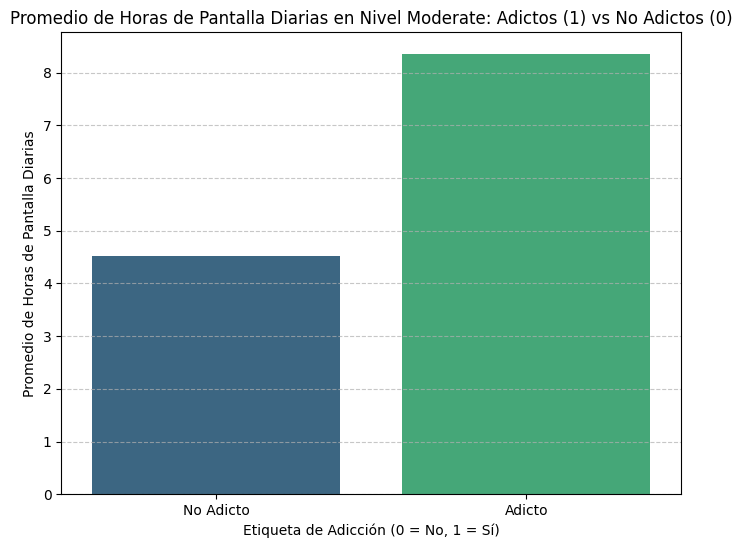

In [ ]:

moderate_group = df[df['addiction_level'] == 'Moderate']


average_daily_screen_time = moderate_group.groupby('addicted_label')['daily_screen_time_hours'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='addicted_label', y='daily_screen_time_hours', data=average_daily_screen_time, palette='viridis')

plt.title('Promedio de Horas de Pantalla Diarias en Nivel Moderate: Adictos (1) vs No Adictos (0)')
plt.xlabel('Etiqueta de Adicción (0 = No, 1 = Sí)')
plt.ylabel('Promedio de Horas de Pantalla Diarias')
plt.xticks([0, 1], ['No Adicto', 'Adicto'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
co(wait=True)
plt.show()

ACA REALIZAMOS UN FILTRO DE NIVEL DE ADICCION EN DONDE EVALUAMOS LOS MODERADOS EN DONDE CALCULAMOS
# El promedio de horas de uso de pantalla diario (daily_screen_time_hours), segmentado por cada categoría de adicción (addicted_label), exclusivamente dentro del subgrupo "moderado" (moderate_group).

PARA VER EN UN GRAFICO LA CANTIDAD Y DIFERENCIAS QUE EXISTEN EN LA CATEGORIA MODERADOS ENTRE ADICTOS Y NO ADICTOS BASANDONOS EN LA CANTIDAD DE HORAS QUE ESTOS ESTAN FRENTE A PANTALLA QUE ESTA VARIABLE ES LA MAS IMPORTANTE PARA PODER CLASIFICAR SI ES ADICTO O NO

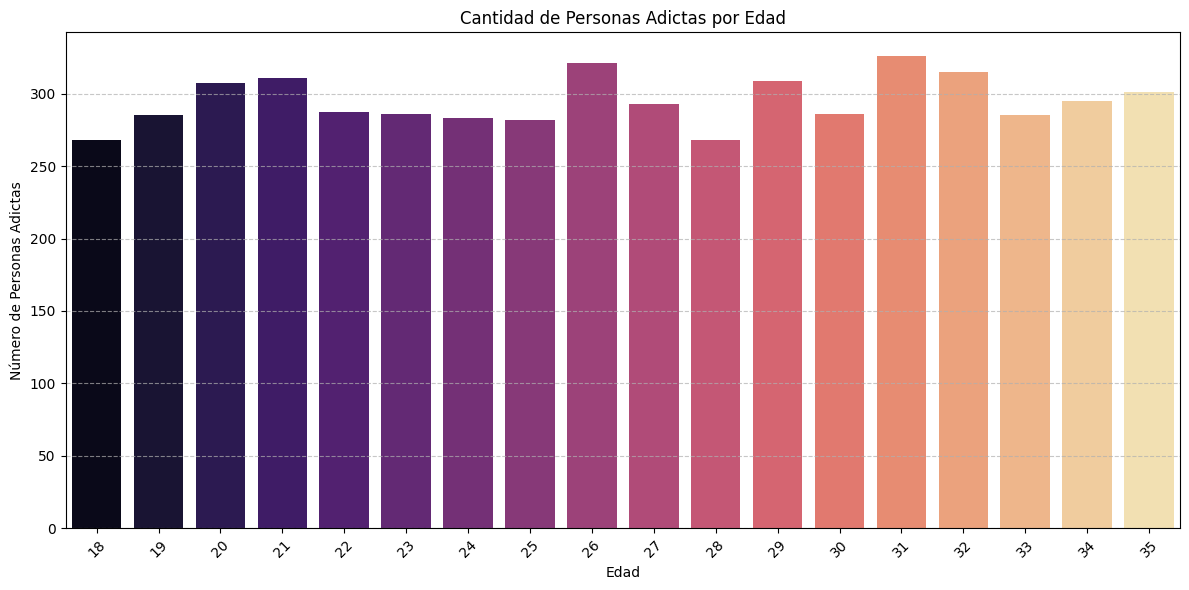

In [ ]:

# Filtrar el DataFrame para obtener solo a las personas adictas
addicted_people = df[df['addicted_label'] == 1]

# Contar la cantidad de personas adictas por edad
addiction_by_age = addicted_people['age'].value_counts().sort_index().reset_index()
addiction_by_age.columns = ['age', 'count_of_addicted']


plt.figure(figsize=(12, 6))
sns.barplot(x='age', y='count_of_addicted', data=addiction_by_age, palette='magma')

plt.title('Cantidad de Personas Adictas por Edad')
plt.xlabel('Edad')
plt.ylabel('Número de Personas Adictas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
co(wait=True)
plt.show()

> filtramos el dataset para aislar exclusivamente a los usuarios clasificados como adictos (addicted_label == 1). Luego, contamos la cantidad exacta de estas personas para cada edad y generamos un gráfico de barras para visualizar estos conteos cronológicamente.

> Nos permite descubrir si existe una tendencia demográfica vinculada a la adicción. Al observar el gráfico, podemos analizar fácilmente si el comportamiento adictivo se concentra en un rango de edad específico (por ejemplo, usuarios más jóvenes) o si, por el contrario, se distribuye de manera relativamente uniforme a lo largo de todas las edades evaluadas (entre los 18 y 35 años).

> Utilizamos un gráfico de barras (sns.barplot) porque es la herramienta visual más efectiva para comparar frecuencias absolutas a través de categorías discretas o secuenciales


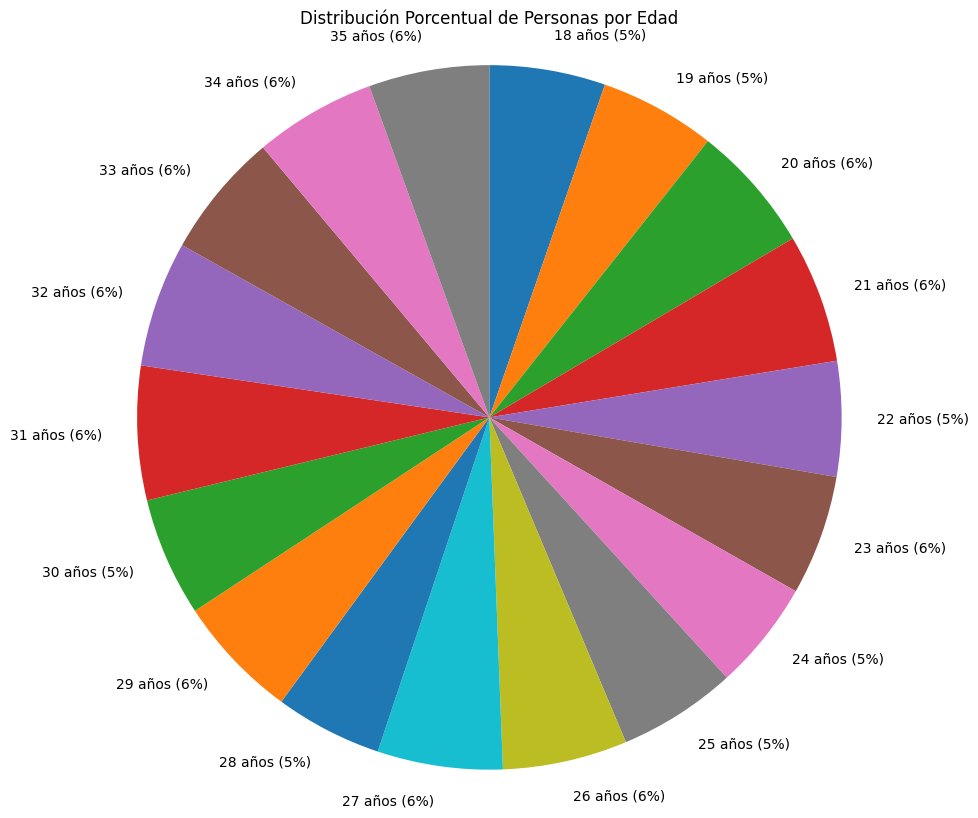

In [ ]:

# Calcular el conteo de cada edad
age_counts = df['age'].value_counts().sort_index()

# Calcular los porcentajes
age_percentages = age_counts / age_counts.sum() * 100

# Crear las etiquetas para el gráfico de torta incluyendo la edad (como entero) y el porcentaje (sin decimales)
labels = [f'{int(age)} años ({percent:.0f}%)' for age, percent in age_percentages.items()]

plt.figure(figsize=(10, 10))
plt.pie(age_counts, labels=labels, autopct='', startangle=90, counterclock=False)
plt.title('Distribución Porcentual de Personas por Edad')
plt.axis('equal')
plt.show()

>Calculando la cantidad total de personas para cada edad en el dataset completo, transformando esos valores matemáticos en porcentajes, y visualizándolos mediante un gráfico de torta (pie chart)

> con esto podemosentender la composición demográfica de nuestra muestra en términos de proporciones relativas. En este caso específico, el resultado nos revela un hallazgo clave sobre la calidad de la muestra: nuestro dataset está perfectamente balanceado. Como se puede observar, cada edad (desde los 18 hasta los 35 años) representa casi la misma proporción exacta del total (entre un 5% y un 6%). Esto nos garantiza que los datos no están sesgados hacia un grupo de edad en particular

>Elegimos este tipo de gráfico porque su función estadística principal es mostrar "partes de un todo"

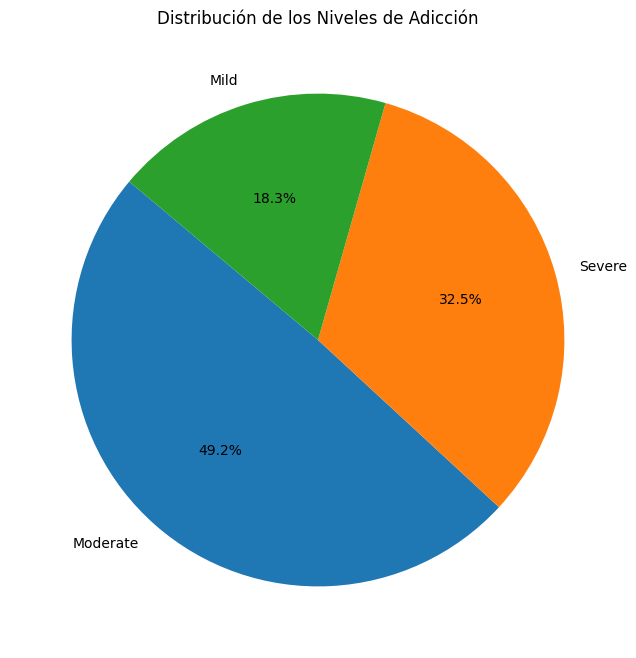

In [ ]:
addiction_counts = df['addiction_level'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(addiction_counts, labels=addiction_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de los Niveles de Adicción')
plt.ylabel('') # Elimina el "Cantidad de Usuarios" redundante para el gráfico de torta
plt.show()

El gráfico revela una tendencia preocupante hacia niveles de adicción elevados, donde la categoría "Moderate" domina el conjunto de datos con un 49.2%, seguida por un significativo 32.5% en el nivel "Severe".

Al sumar ambos segmentos, se concluye que el 81.7% de los individuos analizados presentan una adicción de moderada a grave, mientras que solo una minoría del 18.3% se sitúa en el nivel "Mild".

Esta distribución sugiere que la gran mayoría de la población de la muestra requiere atención o intervención, destacando que el volumen de casos críticos y moderados supera por mucho a los casos leves, lo que podría indicar una muestra sesgada hacia poblaciones ya vulnerables o una problemática profundamente arraigada.

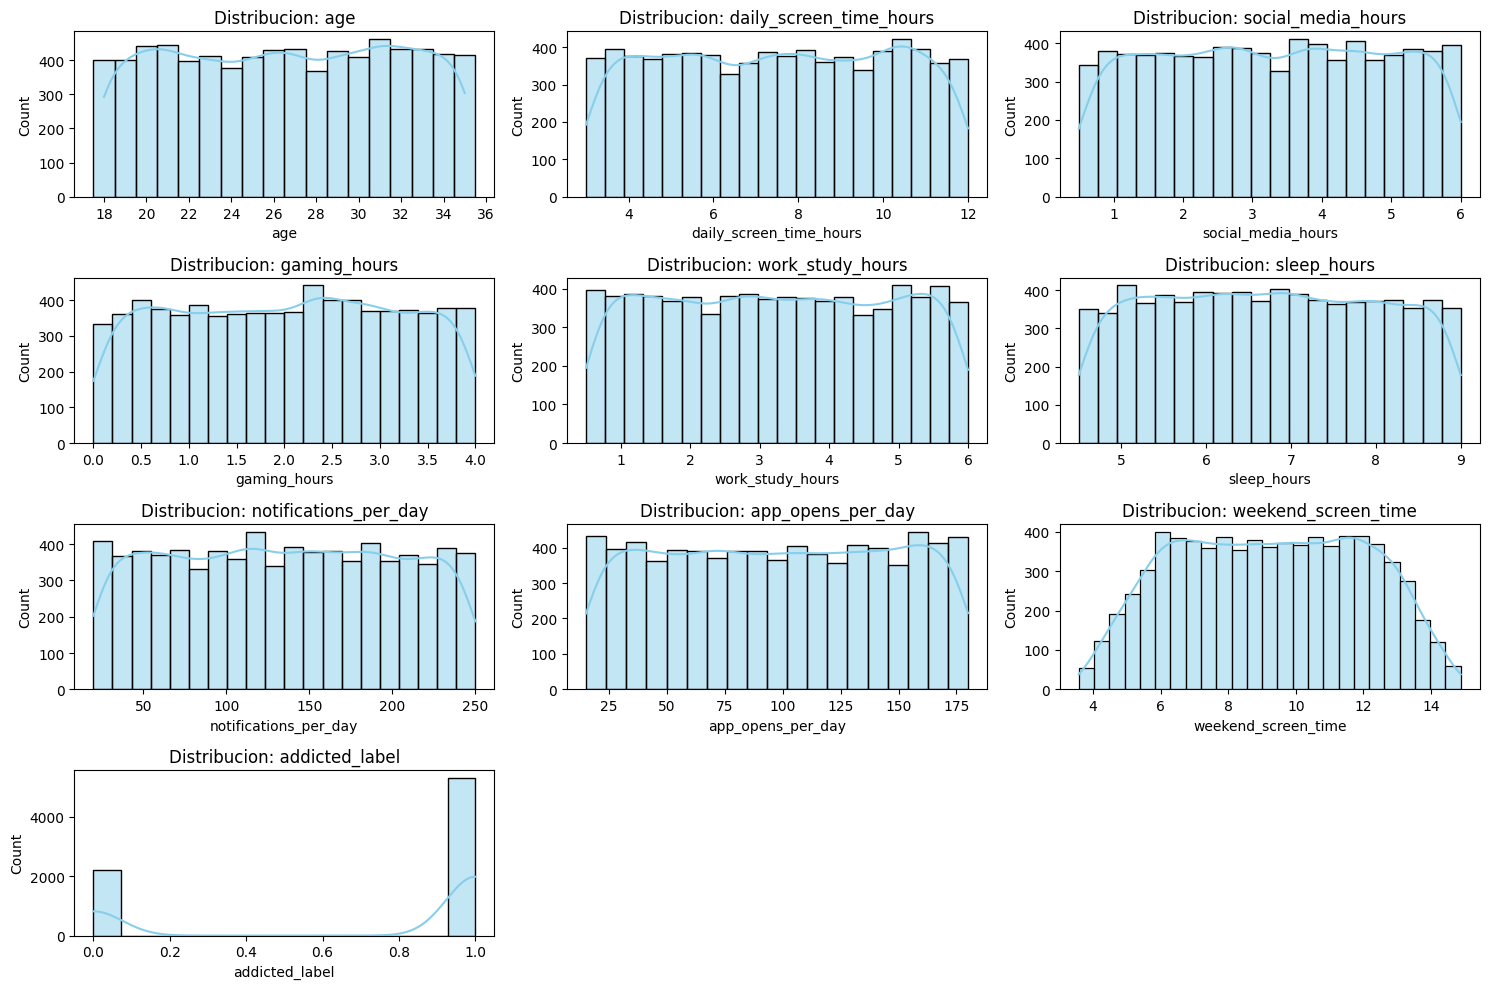

In [ ]:

cols_numericas = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time", "addicted_label",
]

# Configuracion de graficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    # Capturamos el "eje" actual (subplot) en la variable 'ax'
    ax = plt.subplot(4, 3, i)

    if col == 'age':
        sns.histplot(df[col], kde=True, color='skyblue', discrete=True)
        # Forzamos a que las etiquetas del eje X sean solo números enteros
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        sns.histplot(df[col], kde=True, color='skyblue')

    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()

Este conjunto de histogramas revela que casi todas las variables numéricas (como la edad, las horas de redes sociales, el tiempo de estudio y las notificaciones) presentan una **distribución uniforme**, lo que significa que los datos están repartidos de manera prácticamente equitativa en todos los rangos y no hay una tendencia o "pico" natural en el comportamiento de los usuarios. La única excepción notable es el gráfico de **"weekend_screen_time"**, que muestra una distribución más cercana a una campana, con una concentración mayor de personas pasando entre 6 y 12 horas frente a la pantalla los fines de semana, bueno, finalmente, el histograma de **"addicted_label"** confirma visualmente lo que en el grafico que se vio antes, el grafico de tortas donde se ve que existe una gran mayoría de la muestra se agrupa en el valor más alto (cercano a 1.0), indicando que el dataset está compuesto por mas individuos con altos niveles de adicción.

# Histograma

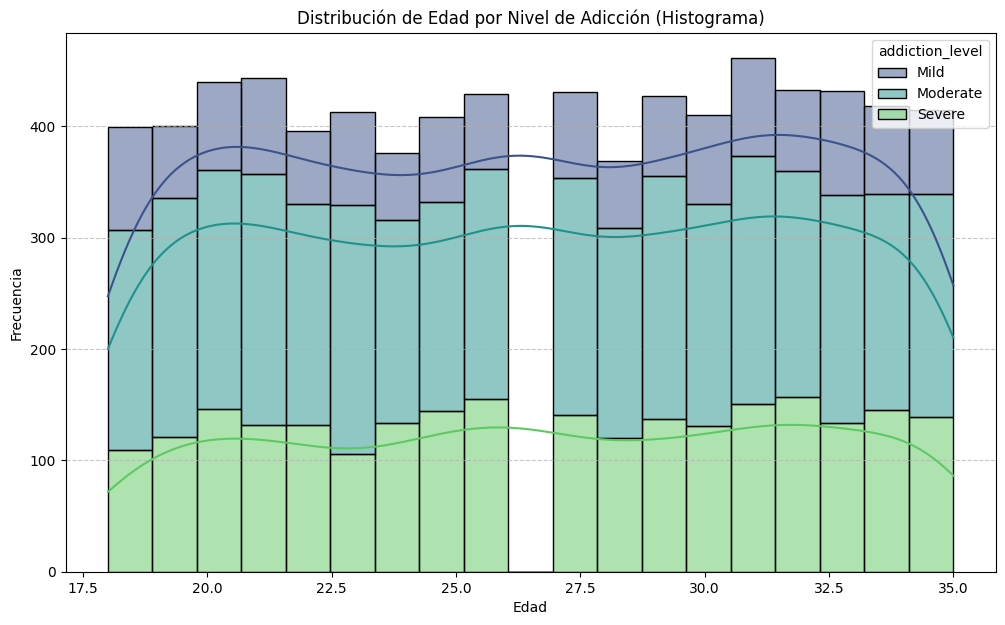

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age', hue='addiction_level', multiple='stack', kde=True, palette='viridis', hue_order=['Mild', 'Moderate', 'Severe'])
plt.title('Distribución de Edad por Nivel de Adicción (Histograma)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Este código genera un histograma apilado que muestra cómo se distribuye la edad entre los diferentes niveles de adicción (leve, moderado, severo). Permite ver la frecuencia de cada edad y la proporción de cada nivel de adicción dentro de esos grupos de edad.

Interpretación del gráfico: El gráfico muestra la distribución de edades en relación con los niveles de adicción. Podemos observar que:

Rangos de Edad: La mayoría de los participantes se encuentran entre los 18 y 35 años, como se esperaba. La distribución de edad para los niveles de adicción 'Mild' y 'Moderate' parece seguir un patrón similar, con una mayor concentración en las edades más jóvenes y una disminución a medida que aumenta la edad.

Adicción Severa: Los individuos con un nivel de adicción 'Severe' parecen estar más presentes en los rangos de edad más jóvenes, disminuyendo significativamente en las edades más avanzadas. Esto podría sugerir que la adicción severa es más común o se manifiesta con mayor intensidad en personas más jóvenes dentro de esta muestra.

Adicción Moderada y Leve: Los niveles de adicción 'Moderate' y 'Mild' se distribuyen de manera más uniforme a lo largo de los rangos de edad, aunque aún con una ligera tendencia a ser más prevalentes en edades más tempranas.

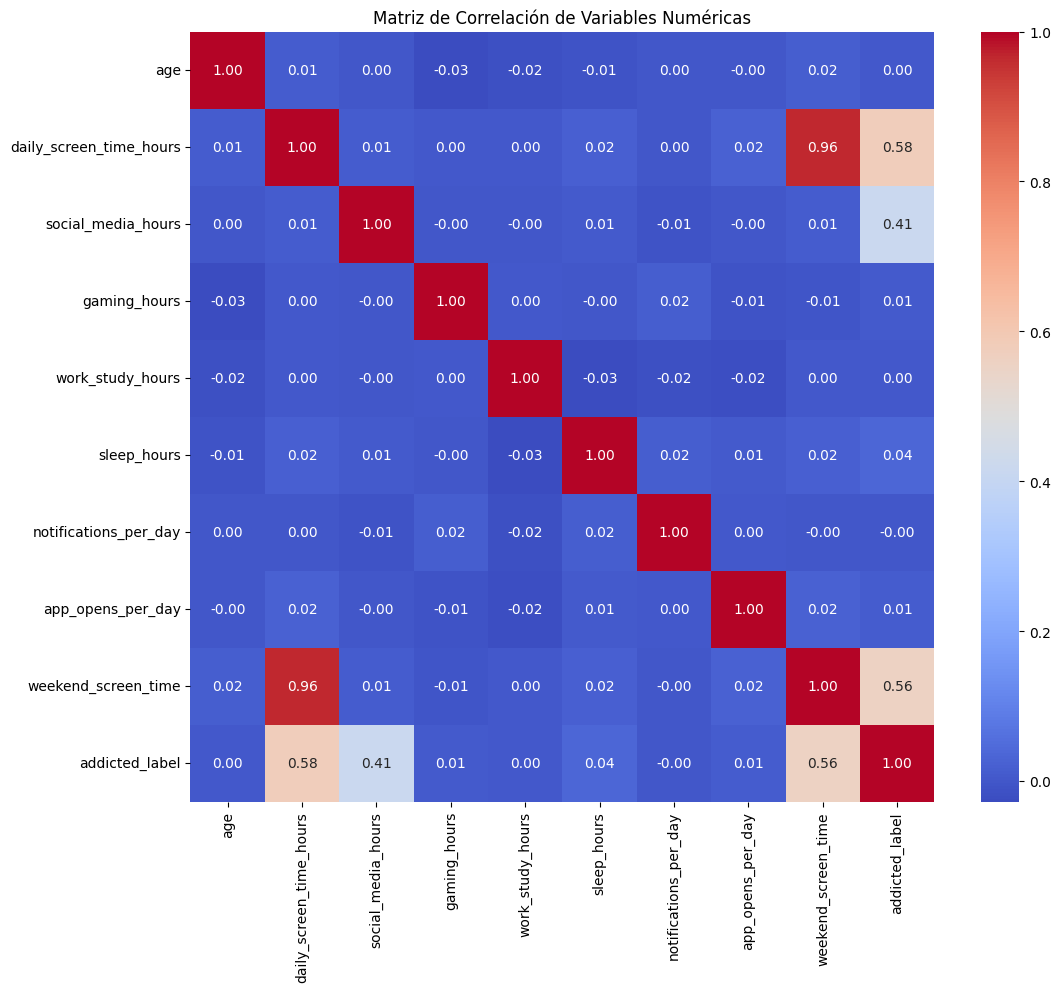

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Esta matriz de correlación (heatmap) analiza la relación entre diversas variables de comportamiento digital, y la conclusión principal es que el tiempo frente a la pantalla es el predictor más fuerte de la adicción. Se observa una correlación casi perfecta (0.96) entre daily_screen_time_hours y weekend_screen_time, lo que indica que los hábitos de uso son consistentes durante toda la semana. Respecto a la variable addicted_label, esta presenta una correlación positiva moderada-alta con el tiempo diario en pantalla (0.58) y el tiempo de fin de semana (0.56), seguida por el uso de redes sociales (0.41), sugiriendo que a mayor tiempo de exposición, mayor es el nivel de adicción reportado. Por el contrario, variables como la edad, las horas de sueño, el trabajo/estudio o la cantidad de notificaciones muestran correlaciones cercanas a cero, lo que implica que, en este conjunto de datos, estos factores no influyen directamente en la probabilidad de adicción de manera lineal.

### Tratamiento de Outliers mediante el Método IQR

Vamos a filtrar los outliers de las columnas numéricas continuas principales para asegurar que los análisis posteriores no estén sesgados por valores extremos.

In [ ]:
cols_continuas = [
    'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'weekend_screen_time'
]

def limpiar_outliers_iqr(df_input, columnas):
    df_limpio = df_input.copy()
    for col in columnas:
        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Filtrar el DataFrame
        antes = df_limpio.shape[0]
        df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior)]
        despues = df_limpio.shape[0]
        print(f'Columna {col}: Eliminados {antes - despues} outliers')

    return df_limpio

# Aplicar la limpieza
df_sin_outliers = limpiar_outliers_iqr(df, cols_continuas)

print(f'\nDimensiones originales: {df.shape}')
print(f'Dimensiones finales tras limpieza: {df_sin_outliers.shape}')
display(df_sin_outliers.describe())

Columna daily_screen_time_hours: Eliminados 0 outliers
Columna social_media_hours: Eliminados 0 outliers
Columna gaming_hours: Eliminados 0 outliers
Columna work_study_hours: Eliminados 0 outliers
Columna sleep_hours: Eliminados 0 outliers
Columna weekend_screen_time: Eliminados 0 outliers

Dimensiones originales: (7500, 16)
Dimensiones finales tras limpieza: (7500, 16)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


>Estamos aplicando una función (limpiar_outliers_iqr) que automatiza la detección y eliminación de valores atípicos en nuestras variables numéricas continuas principales

>Nos permite "sanear" el dataset, garantizando que nuestros análisis estadísticos y modelos posteriores no se vean distorsionados o sesgados por registros extremos

>Elegimos este método porque es una medida estadística robusta. A diferencia de otros enfoques (como el Z-score basado en la media y desviación estándar), el IQR utiliza la mediana y los cuartiles (Q1 y Q3), lo que significa que el propio cálculo de los límites no se ve afectado por los valores extremos que precisamente queremos eliminar

In [ ]:
df_sin_outliers.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,Moderate,0


### Codificación de Variables Categóricas

Utilizaremos `OneHotEncoder` para las variables nominales y un mapeo manual para las variables ordinales, asegurando que el modelo pueda procesar la información correctamente.

In [ ]:
# definiimos las columnas que vamos a modificar
nominal_cols = ['gender', 'academic_work_impact']

# aplicamos el onehotencoder luego de instanciar
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df_sin_outliers[nominal_cols])

# nuevo dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(nominal_cols), index=df_sin_outliers.index)

# Concatenamos con el DataFrame original y eliminamos las columnas viejas
df_final = pd.concat([df_sin_outliers.drop(columns=nominal_cols), encoded_df], axis=1)

print("Nuevas columnas generadas por OneHotEncoder:")
display(encoded_df.head())

print("\nEstructura del DataFrame final:")
display(df_final.head())

Nuevas columnas generadas por OneHotEncoder:


,gender_Male,gender_Other,academic_work_impact_Yes
0,1.0,0.0,1.0
1,0.0,1.0,1.0
2,0.0,1.0,0.0
3,0.0,1.0,1.0
4,1.0,0.0,0.0



Estructura del DataFrame final:


,transaction_id,user_id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,addiction_level,addicted_label,gender_Male,gender_Other,academic_work_impact_Yes
0,TXN00001,U00001,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Moderate,0,1.0,0.0,1.0
1,TXN00002,U00002,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Moderate,0,0.0,1.0,1.0
2,TXN00003,U00003,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,Mild,0,0.0,1.0,0.0
3,TXN00004,U00004,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Moderate,1,0.0,1.0,1.0
4,TXN00005,U00005,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,Severe,1,1.0,0.0,0.0


## one hot enconder

> Estamos aplicando un OneHotEncoder para transformar nuestras variables categóricas (columnas que contienen texto, como el género) en múltiples columnas nuevas compuestas únicamente por ceros y unos (formato binario).

>Es un paso obligatorio de preparación porque los algoritmos de Machine Learning son puramente matemáticos y no saben interpretar palabras. Con esta transformación, traducimos la información de texto a un lenguaje numérico limpio que el modelo sí puede procesar para encontrar patrones para evitar sesgos matematicos y optimizar el modelo.

### Análisis de Relevancia: Género vs Adicción
Visualizamos la proporción de personas adictas segmentadas por género para determinar si existe una diferencia significativa entre los grupos.
> aca vemos la cantidad en porcentaje de adictos que existe por cada genero

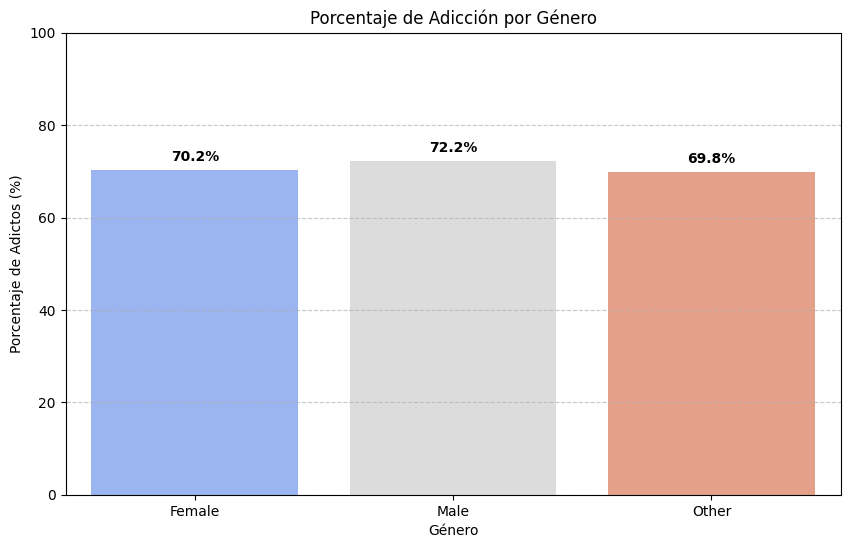

In [ ]:
plt.figure(figsize=(10, 6))
# Calculamos el porcentaje de adicción por género
gender_addiction_pct = df.groupby('gender')['addicted_label'].mean() * 100

sns.barplot(x=gender_addiction_pct.index, y=gender_addiction_pct.values, palette='coolwarm')

plt.title('Porcentaje de Adicción por Género')
plt.xlabel('Género')
plt.ylabel('Porcentaje de Adictos (%)')
plt.ylim(0, 100)

for i, val in enumerate(gender_addiction_pct.values):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')

co(wait=True)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>Estamos agrupando el conjunto de datos según el género de los usuarios (gender) para calcular qué porcentaje exacto de personas dentro de cada grupo está clasificado como adicto (addicted_label). Luego, visualizamos estos porcentajes en un gráfico de barras

>Para identificar si existe una brecha o sesgo de género en el comportamiento adictivo. Los resultados de este gráfico son muy reveladores: nos muestran que la tasa de adicción es alta y sumamente pareja en todas las categorías . Esto nos permite concluir que, dentro de esta muestra, el género no es un factor determinante ni diferenciador para la adicción a las pantallas.

>Usamos un gráfico de barras clásico, pero le agregamos el límite en el eje Y (plt.ylim(0, 100)) para que visualmente represente un "todo" porcentual real, y no exagere las diferencias.

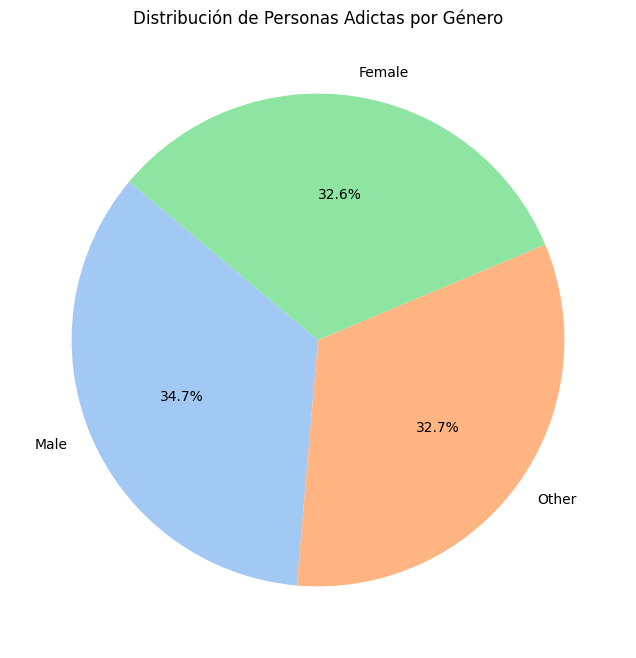

In [ ]:
plt.figure(figsize=(8, 8))

# Filtramos solo a los adictos
addicted_only = df[df['addicted_label'] == 1]
gender_counts = addicted_only['gender'].value_counts()

# Crear el gráfico de torta
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Distribución de Personas Adictas por Género')
plt.show()

A diferencia del gráfico anterior, aquí primero filtramos la base de datos para quedarnos únicamente con las personas que ya están clasificadas como adictas (addicted_label == 1). Luego, contamos cuántos de esos adictos pertenecen a cada categoría de género y lo representamos visualmente.

>nos sirve Para visualizar cómo está compuesto internamente el grupo de personas con adicción. Los resultados nos muestran que el total de usuarios adictos se divide en tres partes casi idénticas

>basandose en el analisis anterior no solo la tasa de adicción es igual en todos los géneros, sino que el grupo total de adictos está perfectamente balanceado.

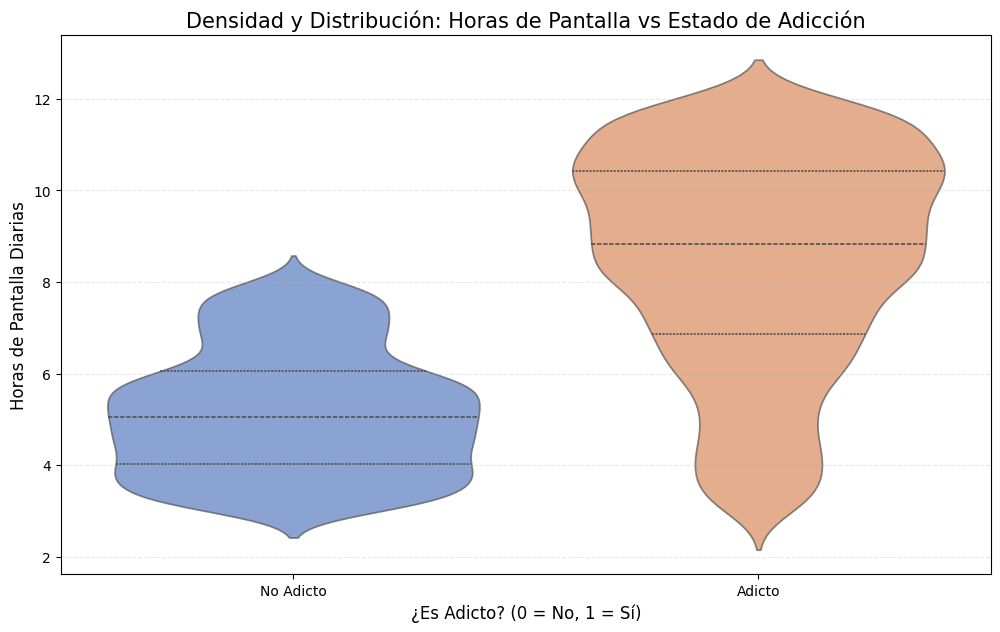

In [ ]:
plt.figure(figsize=(12, 7))

# Creamos el gráfico de violín para ver la densidad
sns.violinplot(x='addicted_label', y='daily_screen_time_hours', data=df,
               palette='muted', inner='quartile', alpha=0.7)

# Añadimos un título y etiquetas claras
plt.title('Densidad y Distribución: Horas de Pantalla vs Estado de Adicción', fontsize=15)
plt.xlabel('¿Es Adicto? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Horas de Pantalla Diarias', fontsize=12)
plt.xticks([0, 1], ['No Adicto', 'Adicto'])

plt.grid(axis='y', linestyle='--', alpha=0.3)
co(wait=True)
plt.show()

Generando un gráfico de violín para comparar cómo se distribuyen y concentran las horas de uso de pantalla diario  (daily_screen_time_hours) y ver la densidad entre el grupo de personas que no son adictas y el grupo de personas clasificadas como adictas.

>Para visualizar de forma clara  la relación directa entre el tiempo de pantalla y la adicción. El gráfico muestra un patrón : el grupo "No Adicto" (azul) concentra su uso diario cerca de las 5 horas, mientras que el grupo "Adicto" (naranja) muestra un uso  mayor, con los usuarios pasando entre 7 y 11 horas frente a la pantalla (con un promedio/mediana cercana a las 9 horas). Esto nos confirma que esta variable es un factor fuertemente discriminante y será clave para nuestro modelo predictivo.

#CONCLUSION


>A modo de cierre, el trabajo realizado sobre este conjunto de datos nos deja un panorama claro y fundamentado sobre los patrones de uso de smartphones y la adicción digital.

>Uno de los hallazgos más interesantes es que la adicción no discrimina por género ni por edad (dentro del rango de 18 a 35 años). Observamos que las tasas de adicción son casi idénticas entre hombres, mujeres y otros géneros, y se distribuyen de forma equitativa en todas las edades analizadas. Esto sugiere que el riesgo de adicción digital es un fenómeno transversal a la identidad del usuario.

>Notamos que variables como las notificaciones o el nivel de estrés no tienen una relación tan directa con la etiqueta de adicción como lo tiene el tiempo total de pantalla. Esto nos permite concluir que el volumen de uso es el síntoma más claro y el predictor definitivo, por encima de las interacciones pasivas (recibir alertas).

>En síntesis, este análisis comprueba que el tiempo de pantalla es la métrica definitiva para evaluar la salud digital. Los hábitos de estos usuarios están sumamente arraigados, al punto de que no hay mayor diferencia entre lo que hacen un martes o un domingo (lo que se refleja en esa altísima correlación de 0.96 entre días de semana y fines de semana). Todo este proceso de limpieza y exploración nos deja un terreno sólido para, en una siguiente etapa, construir modelos predictivos que pongan el foco exactamente ahí: en los tiempos de uso prolongado como la señal de alerta definitiva.